In [2]:
import xarray as xr
import numpy as np
import xesmf as xe
import xskillscore as xs
import scipy as sp
from scipy.optimize import least_squares
import statsmodels.api as sm

import matplotlib.pyplot as plt 
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches 
import matplotlib as mpl
from mpl_toolkits.axisartist.parasite_axes import HostAxes, ParasiteAxes
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.util import add_cyclic_point
import cartopy.feature as cfeature
import cmocean
from mpl_toolkits.axes_grid1 import host_subplot
from mpl_toolkits import axisartist
import matplotlib.gridspec as gridspec
import matplotlib.path as mpath

def delta(var):
    return var.polyfit(dim='year', deg=1).polyfit_coefficients[0]

def glb_avg(sst):
    weight = np.cos(np.deg2rad(sst.lat))
    return (sst).weighted(weight).mean(('lat','lon'))

def spna_avg(var):
    return var.where((var.lat-45)*(var.lat-60)<=0,drop=True).where((var.lon-310)*(var.lat-340)<=0,drop=True).mean(dim=('lat','lon'))

def smooth(var,twindow=15):
    temp = var.rolling(year=twindow,center=True).mean('year')
    return temp 

fdir = '../../data/PTC_out/LE/'
pic_dir = '../../output/figures/'

In [8]:
amoc = xr.open_mfdataset('../../data/CESM2_clean_dataset/AMOCI/CESM2-LE_AMOC40_ts_*.nc',combine='by_coords')['AMOC'].load()
damoc = [-delta(amoc[:,135:165]).mean('rlzn').values, 
         -delta(amoc[:,165:221]).mean('rlzn').values, 
         -delta(amoc[:,221:]).mean('rlzn').values] # delta(amoc[:,:131]).mean('rlzn').values

In [3]:
mask = xr.open_dataset('../../data/CESM2_clean_dataset/PTC_Mask_ref.nc')['mask'] # spatial mask for decompositions
def mask_ptc(ptc, land_mask=mask):
    ptc = ptc.where(~mask.isnull())
    return ptc.where((ptc.lat-70)*(ptc.lat+70)<0)

PTC = {}
PTC['LE | strong AMOC-']  = mask_ptc(xr.open_mfdataset(fdir + '1985-2014/CESM2-LE_PTCterms_*.nc', combine='by_coords')['PTC_term'])
lat0, lon0 = PTC['LE | strong AMOC-'].lat.values, PTC['LE | strong AMOC-'].lon.values
def check_latlon(var,lat0=lat0,lon0=lon0):
    return var.interp(lat=lat0,lon=lon0, method='linear')

PTC['LE | mid AMOC']  = mask_ptc(xr.open_mfdataset(fdir + '2015-2070/CESM2-LE_PTCterms_*.nc', combine='by_coords')['PTC_term'])
PTC['LE | weak AMOC']  = mask_ptc(xr.open_mfdataset(fdir + '2071-2100/CESM2-LE_PTCterms_*.nc', combine='by_coords')['PTC_term'])

In [4]:
H2O_trd = {}
for i in range(3):
    f = xr.open_dataset('../../data/CESM2_clean_dataset/CESM2-LE_H2O_SRF_trd_ensmean_Regime'+str(i+1)+'.nc') ## Needs update
    H2O_trd[str(i)] = f['polyfit_coefficients']/1e-4 # e-5 mol/mol 
    
cld_low = xr.open_mfdataset('../../data/CESM2_clean_dataset/CESM2-LE_CLDLOW_NA_1850-*.nc',combine='by_coords')['CLDLOW']
cld_trd = {}
cld_trd['0'] = delta(cld_low[:,135:165,:,:]).mean('rlzn').load()
cld_trd['1'] = delta(cld_low[:,165:221,:,:]).mean('rlzn').load()
cld_trd['2'] = delta(cld_low[:,221:,:,:]).mean('rlzn').load()

TT = xr.open_mfdataset('../../data/CESM2_clean_dataset/SSTand/CESM2-LE_T_SPNA-GM_*.nc',combine='by_coords')['T'].load()
dT = [delta(TT[:,135:165,:,:]).mean('rlzn'),
      delta(TT[:,165:221,:,:]).mean('rlzn'),
      delta(TT[:,-30:,:,:]).mean('rlzn')]

0 0
1 0
2 0
3 0
0 1
1 1
2 1
3 1
0 2
1 2
2 2
3 2
B&C&D 0
B&C&D 1
B&C&D 2


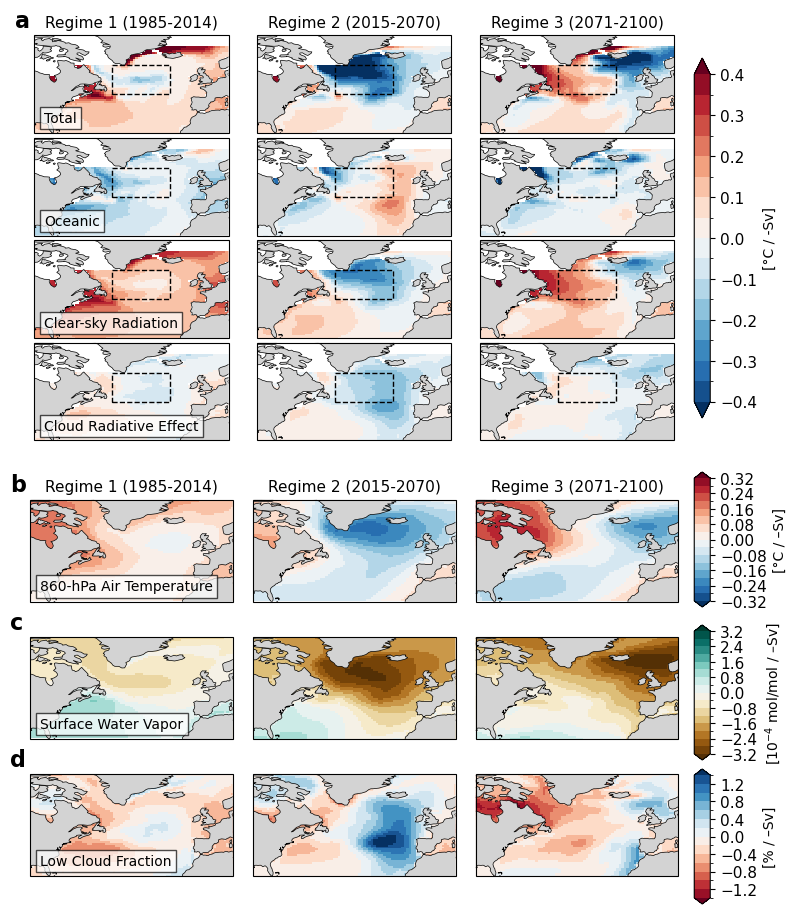

In [9]:
# (a) PTCs
fig, axs0 = plt.subplots(6, 1, constrained_layout=False, figsize=(8, 9))
plt.subplots_adjust(top=0.95,bottom=0.05,left=0.05,right=0.86,wspace=0.1,hspace=0.05)
gridspec = axs0[0].get_subplotspec().get_gridspec()
for a in axs0[:]:
    a.remove()

subfig = fig.add_subfigure(gridspec[:3])
axs = subfig.subplots(4, 3, subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=310)),
                      sharex=True, sharey=True)
terms = ['Total', 'Oceanic','Clear-sky Radiation','Cloud Radiative Effect']
ptc = [PTC['LE | strong AMOC-'], 
       PTC['LE | mid AMOC'],
       PTC['LE | weak AMOC']]
periods = ['(1985-2014)',
           '(2015-2070)',
           '(2071-2100)']

clevs = np.arange(-0.4,0.45,0.05)
for j in range(3):
    temp = [ptc[j].sum('term').mean('rlzn'),ptc[j].isel(term=[5,6]).sum('term').mean('rlzn'),
            ptc[j].isel(term=[3,4]).sum('term').mean('rlzn'),ptc[j].isel(term=[1,2]).sum('term').mean('rlzn')]
    for i in range(4):
        print(i,j)
        temp2plot = mask_ptc((temp[i]-glb_avg(temp[i]))/damoc[j])
        cs = temp2plot.plot(ax=axs[i,j],levels=clevs,transform=ccrs.PlateCarree(),extend='both',add_colorbar=False,add_labels=False)
        axs[i,j].add_feature(cfeature.LAND,zorder=1,fc='lightgrey')
        axs[i,j].add_feature(cfeature.COASTLINE,zorder=1.2, lw=0.5)
        axs[i,j].add_patch(patches.Rectangle((310, 45),30,15,edgecolor = 'black',linestyle='--',linewidth=1,fill=False,transform=ccrs.PlateCarree()))
        axs[i,j].set_extent([-90, 10, 25, 68])
    axs[0,j].set_title('Regime '+str(j+1)+' '+periods[j],loc='center',fontdict={'size': 11})

for i in range(4):
    axs[i,0].text(-35,29,terms[i],size=10,ha='left',va='bottom',color='k',
                  backgroundcolor='w',bbox=dict(boxstyle='square',alpha=0.7,ec='k',fc='w'))

cax = plt.axes([0.88, 0.55, 0.02,0.4])  
cb = plt.colorbar(cs, cax=cax, drawedges=0,orientation='vertical')
cb.set_label('[\u00B0C / -Sv]',fontsize=10)
cb.ax.tick_params(labelsize=11)

axs[0,0].set_title('a',loc='left',fontdict={'weight': 'bold', 'size': 16},x=-0.1)

subfig = fig.add_subfigure(gridspec[3:])
axs = subfig.subplots(3, 3, subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=310)),
                      sharex=True, sharey=True)
for i in range(3):
    print('B&C&D',i)
    data2plot = dT[i]/damoc[i]
    cs0 = data2plot.plot(ax=axs[0,i],levels=np.arange(-0.32,0.36,0.04),extend='both',
                        transform=ccrs.PlateCarree(),add_colorbar=False)

    data2plot = (H2O_trd[str(i)]-glb_avg(H2O_trd[str(i)]))/damoc[i]
    cs1 = data2plot.plot(ax=axs[1,i],levels=np.arange(-3.2,3.6,0.4),extend='both',cmap='BrBG',
                         transform=ccrs.PlateCarree(),add_colorbar=False)
    
    data2plot = cld_trd[str(i)]/damoc[i]*100
    cs2 = data2plot.plot(ax=axs[2,i],levels=np.arange(-1.4,1.6,0.2),extend='both',cmap='RdBu',
                         transform=ccrs.PlateCarree(),add_colorbar=False)    
    axs[0,i].set_title('Regime '+str(i+1)+' '+periods[i],loc='center',fontdict={'size': 11})
    axs[1,i].set_title('')
    axs[2,i].set_title('')
    for j in range(3):
        axs[j,i].add_feature(cfeature.LAND,zorder=1,fc='lightgrey')
        axs[j,i].add_feature(cfeature.COASTLINE,zorder=1.2, lw=0.5)
        axs[j,i].set_extent([-90, 10, 25, 68])  

cax = plt.axes([0.88, 0.34, 0.02,0.15])  
cb = plt.colorbar(cs0, cax=cax, drawedges=0,orientation='vertical')
cb.set_label('[\u00B0C / –Sv]',fontsize=10)
cb.ax.tick_params(labelsize=11)
axs[0,0].set_title('b',loc='left',fontdict={'weight': 'bold', 'size': 16},x=-0.1)

cax = plt.axes([0.88, 0.17, 0.02,0.15])  
cb = plt.colorbar(cs1, cax=cax, drawedges=0,orientation='vertical')
cb.set_label('[10$^{-4}$ mol/mol / –Sv]',fontsize=10)
cb.ax.tick_params(labelsize=11)
axs[1,0].set_title('c',loc='left',fontdict={'weight': 'bold', 'size': 16},x=-0.1)

cax = plt.axes([0.88, 0.01, 0.02,0.15])  
cb = plt.colorbar(cs2, cax=cax, drawedges=0,orientation='vertical')
cb.set_label('[% / –Sv]',fontsize=10)
cb.ax.tick_params(labelsize=11)
axs[2,0].set_title('d',loc='left',fontdict={'weight': 'bold', 'size': 16},x=-0.1)

axs[0,0].text(-35,29,'860-hPa Air Temperature',size=10,ha='left',va='bottom',color='k',
              backgroundcolor='w',bbox=dict(boxstyle='square',alpha=0.7,ec='k',fc='w'))

axs[1,0].text(-35,29,'Surface Water Vapor',size=10,ha='left',va='bottom',color='k',
              backgroundcolor='w',bbox=dict(boxstyle='square',alpha=0.7,ec='k',fc='w'))
axs[2,0].text(-35,29,'Low Cloud Fraction',size=10,ha='left',va='bottom',color='k',
              backgroundcolor='w',bbox=dict(boxstyle='square',alpha=0.7,ec='k',fc='w'))

plt.savefig(pic_dir+'F3_decomposed_maps.pdf')
plt.show()